In [2]:
from collections import Counter
import pickle
import os
from math import comb

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

import math
import os
import time
import glob
import types

import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib import rc

direction='in'
mpl.rcParams.update({
'font.family' : 'Arial',
'mathtext.fontset' : 'cm',
'xtick.direction' : f'{direction}' ,
'ytick.direction' : f'{direction}' ,
'xtick.labelsize' : 17.5 ,
'xtick.top' : True ,
'xtick.major.width' : 1.5,
'xtick.major.size' : 6,
'ytick.labelsize' : 17.5 ,
'ytick.right' : True ,
'ytick.major.width' : 1.5,
'ytick.major.size' : 6,
'axes.labelsize' : 18,
'legend.frameon' : False,
'legend.fontsize' : 13,
'legend.handlelength' : 2,
'savefig.dpi' : 600, 
'savefig.bbox' : 'tight',
'axes.linewidth' : 1.5,
})
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import os.path as path
import pickle
import re
import seaborn as sns

from scipy import stats


import tqdm
import time

def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [7]:
def is_non_zero_file(fpath, verb=False, n=10, filelen = 1):
    result = os.path.isfile(fpath) and os.path.getsize(fpath) > 0
    if not result:
        if verb: print('No', fpath); 
    else:
        _ = np.loadtxt(fpath, dtype='float64')
        result = result and _.reshape(-1).shape[0]//n > filelen
        # if verb: print(_.shape)
        if not result: 
            if verb: print('No', fpath, _.shape); 
    return result
color_r = ['#20DF90', '#3CAFA4', '#5880B8', '#7450CB', '#9020DF', '#db1aed', '#fc3fc3', '#fc83b0']
color_L = {8: sns.color_palette('rocket_r',7)[0], 10: sns.color_palette('rocket_r',7)[1], \
           12: sns.color_palette('rocket_r',7)[2], 14: sns.color_palette('rocket_r',7)[3],\
          16: sns.color_palette('rocket_r',7)[4], 18: sns.color_palette('rocket_r',7)[5], \
          20: sns.color_palette('rocket_r',7)[6]}
color_s = {1:'#20DF90', 4:'#3CAFA4', 16:'#5880B8', 64:'#7450CB', \
           128:'#9020DF', 256: '#db1aed', 512:'#fc3fc3', 1024: '#fc83b0' }
Ls = np.array([8,10,12,14,16,18,20])
setsizes = np.array([1,4,16,64,128,256,512,1024])

# Fig.3

6000000
[[0.56218112 0.56412476 0.56279762 0.56222971]
 [0.58008989 0.58088405 0.55765002 0.57409196]
 [0.61402302 0.57411322 0.60832422 0.61088891]
 [0.68607416 0.68048318 0.68015822 0.67019406]
 [0.7668337  0.761513   0.74378492 0.76367074]
 [0.97085004 0.97241405 0.96201713 0.97754495]
 [0.9944986  0.99395651 0.99295281 0.99507106]]
6000000
[[0.5000167  0.50010022 0.54715136 0.54826288]
 [0.49989978 0.56997085 0.5               nan]
 [0.60364128 0.49984967 0.49993319 0.60082756]
 [0.58367651 0.55694546 0.63955752 0.62653972]
 [0.58678025 0.50020044 0.72687379 0.50023384]
 [0.81925261 0.7803374  0.75594023 0.77976039]
 [0.70494868 0.78413205 0.84340683 0.91458941]]
6000000
[[0.50006681 0.50006681 0.50005011 0.50011692]
 [0.50030066 0.50008352 0.49974945 0.50003341]
 [0.49989978 0.49996659 0.50008352 0.50026725]
 [0.50005011 0.50003341 0.50011692 0.50008352]
 [0.50018373 0.49988308 0.49996659 0.50011692]
 [0.49979956 0.49989978 0.49996659 0.49988308]
 [0.50016703 0.4999833  0.50006681

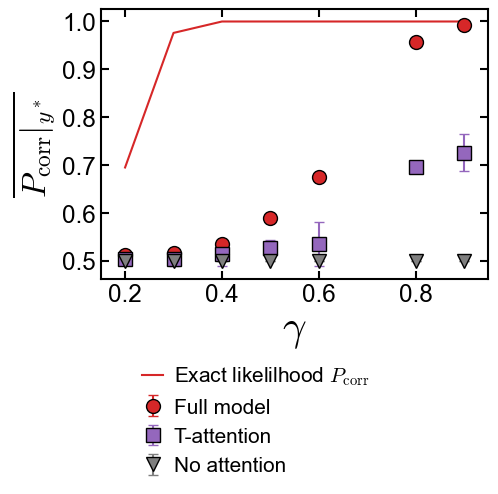

In [24]:
shape = {'SMLP_Tbt2': 's', 'QuAN4_Tbt2': 'o', 'SMLP_Tbm2': 'v'}
name = {'QuAN4_Tbt2':'Full model', \
        'SMLP_Tbm2':'No attention', 'SMLP_Tbt2':'T-attention'}
cmodel = {'QuAN4_Tbt2': 'tab:red', 'SMLP_Tbt2': 'tab:purple', 'SMLP_Tbm2': 'tab:gray'}
cmodel_e = {'QuAN4_Tbt2': sns.color_palette("dark")[3], 'SMLP_Tbt2': sns.color_palette("dark")[4],\
            'SMLP_Tbm2': sns.color_palette("dark")[7]}

L = 12; setsize = 64
mn = 'QuAN4_Tbt2'
cm = {6000000:'tab:red', 600000:'tab:pink', 300000:'tab:cyan', 100000:'tab:grey', 60000:'tab:cyan'}

fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
fraction = 6000000
for mn in ['QuAN4_Tbt2', 'SMLP_Tbt2', 'SMLP_Tbm2']:
    test_gs = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9])
    accs = np.zeros((len(test_gs), 4)); accs[:] = np.nan
    creds = np.zeros((len(test_gs), 4)); creds[:] = np.nan
    for i,gamma in enumerate(test_gs):
        f_ = fraction; nh = 1
        for run in range(4):
            fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
            +f'cred_{L}_g{gamma}_0vs{f_}-{mn}_set{setsize}__h16nh{nh}_ch4ker2st1.txt'
            if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
            vl_ac, vl_cred = np.loadtxt(fn, unpack=True)
            creds[i, run] = vl_cred
            accs[i,run] = vl_ac
    print(fraction)
    print(accs)
    ax.errorbar(test_gs, np.nanmean(creds, axis=-1), yerr=np.nanstd(accs, axis=-1)/np.sqrt(4),\
                fmt=shape[mn], capsize=3.5, lw=1.5, elinewidth=1.5, ms=10, c=cmodel[mn], \
                mec='k', label=name[mn])

g = np.array([0.2  , 0.25 , 0.3  , 0.35 , 0.375, 0.4  , 0.45 , 0.5  , 0.6  , 0.8  , 0.9, 0.975  ])
n64_l12_acc = np.array([0.7808549789322097, 0.9071150461357939, 0.9838924742652941, 0.9992932956424343, 0.9998799935996586, 0.9999866659555177, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])


gamma_pts = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]
cred_L12_N64 = [0.52410, 0.69485, 0.97612, 0.99998, 0.99999, 0.99999, 0.99999, 0.99999, 0.99999, 0.99999]

ax.plot(gamma_pts[1:-1], cred_L12_N64[1:-1], '-', c='tab:red', label=r'Exact likelilhood $P_\mathrm{corr}$')

ax.legend(bbox_to_anchor=(0.74,-0.25), fontsize=15, handlelength=1, handletextpad=0.5, columnspacing=1)
#ax.set_ylim(48, 102)
ax.set_xlim(0.15,0.95)
ax.set_xlabel(r'$\gamma$', fontsize=30)
ax.set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=24)
ax.set_yticks([0.5,0.6,0.7,0.8,0.9,1.0])
# plt.savefig('fig3a.pdf', dpi=400, transparent=True)
plt.show()

72000000
72000000


/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55630/3072457347.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[init,0].set_yticklabels(['0.00','0.25','0.50','0.75', '1.00'])
/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55630/3072457347.py:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_xticklabels(['', r'$0$',r'$2$',r'$4$'])
/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55630/3072457347.py:61: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_yticklabels([r'$0.00$',r'$0.25$',r'$0.50$',r'$0.75$', r'$1.00$'])
/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55630/3072457347.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_yticklabels([r'$0$',r'$2\cdot10^{-4}$',r'$4\cdot10^{-4}$',r'$1$'])


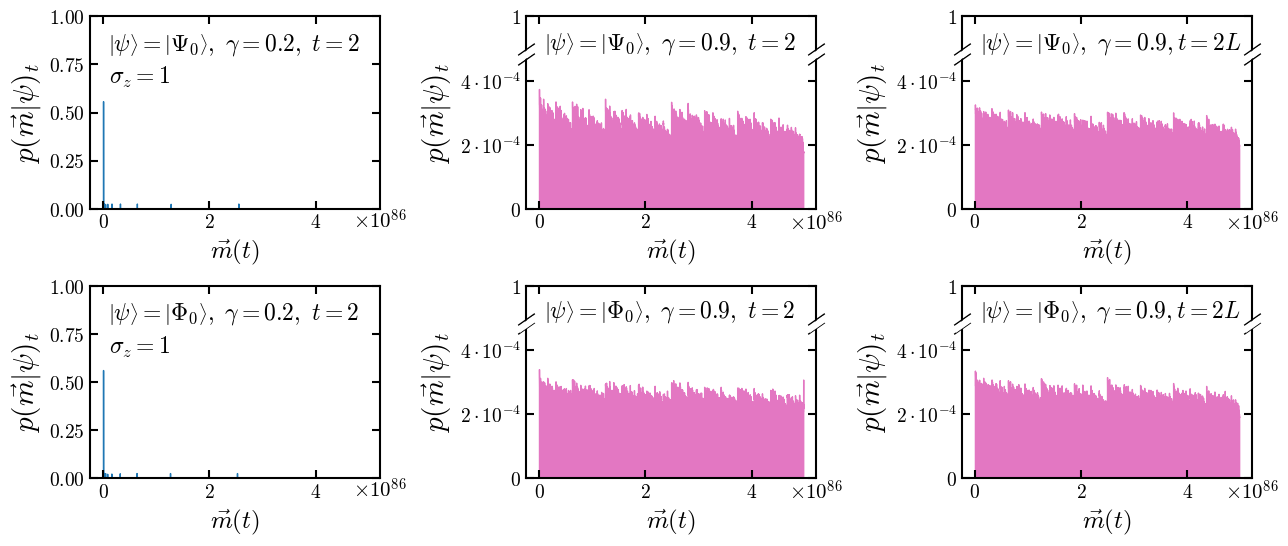

In [4]:
L = 12
D = 2**(2*L*L)
d = 2**L
M=6000000

add=''

fig,ax = plt.subplots(2,3,figsize=(15,6))

for init in [0,1]:
    t=1
    fn = f'Data_out/StateDistinguish/counts_M={M},L={L},add={add},init={init},gamma=0.2,perm=t={t}.npz'
    data = np.load(fn)['c']
    ax[init,0].fill_between(np.asarray(np.arange(d)*D/d, dtype=np.float64), \
                               0, np.asarray(data, dtype=np.float64)/np.sum(data), color='tab:blue')
    print(np.sum(data))
    ax[init,0].set_ylim(0,1)
    ax[init,0].set_yticklabels(['0.00','0.25','0.50','0.75', '1.00'])
    
init = 0
for i,t in enumerate([2,'2L']):
    fn = f'Data_out/StateDistinguish/counts_M={M},L={L},add={add},init={init},gamma=0.9,perm=t={t}.npz'
    data = np.load(fn)['c']
    ax[0,i+1].fill_between(np.asarray(np.arange(d)*D/d, dtype=np.float64), \
                           0, np.asarray(data, dtype=np.float64)/np.sum(data), color='tab:pink')

init = 1
for i,t in enumerate([2,'2L']):
    fn = f'Data_out/StateDistinguish/counts_M={M},L={L},add={add},init={init},gamma=0.9,perm=t={t}.npz'
    data = np.load(fn)['c']
    ax[1,i+1].fill_between(np.asarray(np.arange(d)*D/d, dtype=np.float64), \
                           0, np.asarray(data, dtype=np.float64)/np.sum(data), color='tab:pink')
    #else: ax[1,i+1].plot(np.arange(d)*D/d, data/(M), lw=0.3, color='tab:pink')
    
    
pad = plt.rcParams["xtick.major.size"] + plt.rcParams["xtick.major.pad"]
def bottom_offset(self, bboxes, bboxes2):
    bottom = self.axes.bbox.ymin
    self.offsetText.set(va="top", ha="left") 
    oy = bottom - 0.2*pad * self.figure.dpi / 72.0
    self.offsetText.set_position((0.9, oy))
    
ax[0,0].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
ax[0,1].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
ax[0,2].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
ax[1,0].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
ax[1,1].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
ax[1,2].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
ax[0,0].set_ylabel(r'$p(\vec{m}|\psi)_{t}$', fontsize=21)
ax[0,1].set_ylabel(r'$p(\vec{m}|\psi)_{t}$', fontsize=21)
ax[0,2].set_ylabel(r'$p(\vec{m}|\psi)_{t}$', fontsize=21)
ax[1,0].set_ylabel(r'$p(\vec{m}|\psi)_{t}$', fontsize=21)
ax[1,1].set_ylabel(r'$p(\vec{m}|\psi)_{t}$', fontsize=21)
ax[1,2].set_ylabel(r'$p(\vec{m}|\psi)_{t}$', fontsize=21)

for a in ax.flatten():
    a.tick_params(axis='x', labelsize=14)  # x-axis tick labels
    a.tick_params(axis='y', labelsize=14)
    a.set_xticklabels(['', r'$0$',r'$2$',r'$4$'])
for a in ax[:,0].flatten():
    a.set_yticklabels([r'$0.00$',r'$0.25$',r'$0.50$',r'$0.75$', r'$1.00$'])
    a.text(4.7e86, -1e-1, r'$\times 10^{86}$', fontsize=15)
for a in ax[:,1:].flatten():  
    a.set_ylim(0,6e-4)
    #a.set_yticks([0,2e-3,4e-3,8e-3])
    a.set_yticklabels([r'$0$',r'$2\cdot10^{-4}$',r'$4\cdot10^{-4}$',r'$1$'])
    a.text(4.7e86, -0.65e-4, r'$\times 10^{86}$', fontsize=15)
    
    d = .7  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                  linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    a.plot([0, 1], [0.72+0.06, 0.72+0.06], transform=a.transAxes, **kwargs)
    a.plot([0, 1], [0.77+0.06, 0.77+0.06], transform=a.transAxes, **kwargs)
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                  linestyle="none", color='w', mec='w', mew=4.5, clip_on=False)
    a.plot([0, 1], [0.7465+0.0575, 0.7465+0.0575], transform=a.transAxes, **kwargs, zorder=30)

    
ax[0,0].text(1e85, 0.825, r'$\left|\psi\right\rangle =\left|\Psi_0\right\rangle, \ \gamma=0.2, \ t=2$', fontsize=17)
ax[1,0].text(1e85, 0.825, r'$\left|\psi\right\rangle =\left|\Phi_0\right\rangle, \ \gamma=0.2, \ t=2$', fontsize=17)
ax[0,0].text(1.1e85, 0.65, r'$\sigma_z=1$', fontsize=17)
ax[1,0].text(1.1e85, 0.65, r'$\sigma_z=1$', fontsize=17)
ax[0,1].text(1e85, 0.0005, r'$\left|\psi\right\rangle =\left|\Psi_0\right\rangle, \ \gamma=0.9, \ t=2$', fontsize=17)
ax[1,1].text(1e85, 0.0005, r'$\left|\psi\right\rangle =\left|\Phi_0\right\rangle, \ \gamma=0.9, \ t=2$', fontsize=17)
ax[0,2].text(1e85, 0.0005, r'$\left|\psi\right\rangle =\left|\Psi_0\right\rangle, \ \gamma=0.9, t=2L$', fontsize=17)
ax[1,2].text(1e85, 0.0005, r'$\left|\psi\right\rangle =\left|\Phi_0\right\rangle, \ \gamma=0.9, t=2L$', fontsize=17)

    
fig.subplots_adjust(hspace=0.4, wspace=0.5)
# plt.savefig('fig3bg.png', dpi=400)
plt.show()

## SFig

0.2 2 0.5563171527777778
0.2 2L 0.555859


/var/folders/km/qpx_vm0n53z_pvldds5qm8pw0000gn/T/ipykernel_55630/332235543.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_xticklabels(['', r'$0$',r'$2$',r'$4$'])


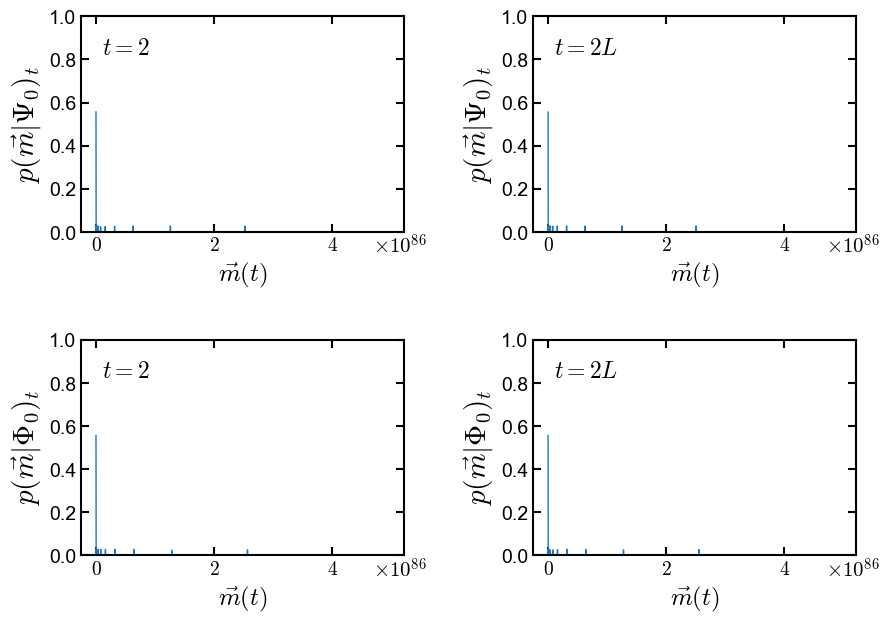

In [6]:
L = 12
D = 2**(2*L*L)
d = 2**L
M=6000000

gamma=0.2
add=''

fig,ax = plt.subplots(2,2,figsize=(10,7))


for i,t in enumerate([2,'2L']):
    init=0
    fn = f'Data_out/StateDistinguish/counts_M={M},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c']
    #for l in range(d):
    #    ax[i,0].axvline(l*D/d, ymin=0, ymax=data[l]/(M*L), lw=0.5)
    ax[0,i].plot(np.arange(d)*D/d, data/(M*L), lw=1)
    
    
    #ax[i,2].hist(data/(M), bins = np.linspace(0,0.5,50), alpha=0.8, zorder=10, label=fr'$\gamma={gamma}$')
    
    init=1
    fn = f'Data_out/StateDistinguish/counts_M={M},L={L},add={add},init={init},gamma={gamma},perm=t={t}.npz'
    data = np.load(fn)['c']
    #for l in range(d):
    #    ax[i,1].axvline(l*D/d, ymin=0, ymax=data[l]/(M*L), lw=0.5)
    ax[1,i].plot(np.arange(d)*D/d, data/(M*L), lw=1)
    print(gamma, t, data.max()/(M*L))
    
for a in ax.flatten():
    #a.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    #a.set_yticklabels([r'$0.00$',r'$0.25$',r'$0.50$',r'$0.75$', r'$1.00$'])
    a.set_xticklabels(['', r'$0$',r'$2$',r'$4$'])
    a.text(4.7e86, -1e-1, r'$\times 10^{86}$', fontsize=15)
    a.xaxis.offsetText.set_visible(False)
    a.tick_params(axis='x', labelsize=14)  # x-axis tick labels
    a.tick_params(axis='y', labelsize=14)
    
    a.set_ylim(0,1)
    #a.set_yscale('log')
    
for i in range(2):
    ax[0,i].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
    ax[1,i].set_xlabel(r'$\vec{m}(t)$', fontsize=18)
    ax[0,i].set_ylabel(r'$p(\vec{m}|\Psi_0)_{t}$', fontsize=21)
    ax[1,i].set_ylabel(r'$p(\vec{m}|\Phi_0)_{t}$', fontsize=21)

ax[0,0].text(0.1e86, 0.825, r'$t=2$', fontsize=17)
ax[1,0].text(0.1e86, 0.825, r'$t=2$', fontsize=17)
ax[0,1].text(0.1e86, 0.825, r'$t=2L$', fontsize=17)
ax[1,1].text(0.1e86, 0.825, r'$t=2L$', fontsize=17)

fig.subplots_adjust(hspace=0.5, wspace=0.4)



6000000
[[0.56218112 0.56412476 0.56279762 0.56222971]
 [0.58008989 0.58088405 0.55765002 0.57409196]
 [0.61402302 0.57411322 0.60832422 0.61088891]
 [0.68607416 0.68048318 0.68015822 0.67019406]
 [0.7668337  0.761513   0.74378492 0.76367074]
 [0.97085004 0.97241405 0.96201713 0.97754495]
 [0.9944986  0.99395651 0.99295281 0.99507106]]
600000
[[0.52919118 0.53225184 0.51257353 0.53378676]
 [0.5217739  0.5055239  0.52647978 0.53417279]
 [0.51170956 0.53372243 0.54387868 0.52226103]
 [0.58132353 0.59241728 0.49949449 0.55959559]
 [0.58908088 0.50077206 0.63745404 0.55768382]
 [0.90248162 0.88319853 0.90334559 0.89644301]
 [0.96626838 0.93836397 0.95417279 0.93772059]]
300000
[[0.50409007 0.50997243 0.5222886  0.50788603]
 [0.51526654 0.50655331 0.54849265 0.5440625 ]
 [0.51748162 0.53409007 0.52736213 0.49795037]
 [0.52115809 0.54086397 0.49965074 0.49939338]
 [0.5182261  0.52175551 0.55825368 0.54204963]
 [0.54380515 0.78661765 0.50671875 0.68039522]
 [0.92492647 0.4959375  0.90043199 0

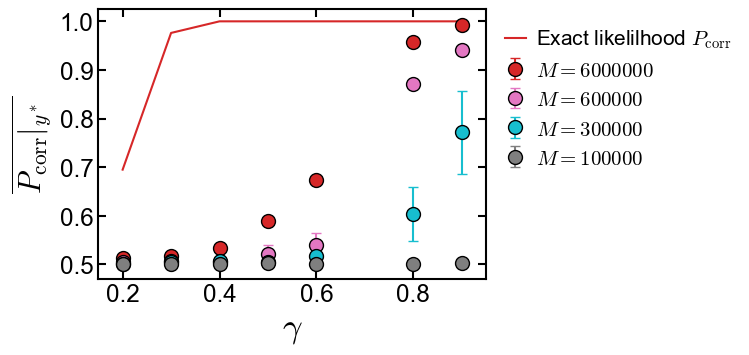

In [12]:
L = 12; setsize = 64
mn = 'QuAN4_Tbt2'
cm = {6000000:'tab:red', 600000:'tab:pink', 300000:'tab:cyan', 100000:'tab:grey', 60000:'tab:cyan'}
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
for fraction in [6000000, 600000, 300000, 100000]:
    test_gs = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9])
    accs = np.zeros((len(test_gs), 4)); accs[:] = np.nan
    creds = np.zeros((len(test_gs), 4)); creds[:] = np.nan
    for i,gamma in enumerate(test_gs):
        f_ = fraction; nh = 1
        for run in range(4):
            fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
            +f'cred_{L}_g{gamma}_0vs{f_}-{mn}_set{setsize}__h16nh{nh}_ch4ker2st1.txt'
            if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
            vl_ac, vl_cred = np.loadtxt(fn, unpack=True)
            creds[i, run] = vl_cred
            accs[i,run] = vl_ac
    print(fraction)
    print(accs)
    ax.errorbar(test_gs, np.nanmean(creds, axis=-1), yerr=np.nanstd(accs, axis=-1)/np.sqrt(4),\
                fmt='o', capsize=3.5, c=cm[fraction], ms=10, mec='k', label=fr'$M={fraction}$')


ax.plot(gamma_pts[1:-1], cred_L12_N64[1:-1], '-', c='tab:red', label=r'Exact likelilhood $P_\mathrm{corr}$')

ax.legend(bbox_to_anchor=(1,1), fontsize=15, handlelength=1, handletextpad=0.5, columnspacing=1)
#ax.set_ylim(48, 102)
ax.set_xlim(0.15,0.95)
ax.set_xlabel(r'$\gamma$', fontsize=25)
ax.set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax.set_yticks([0.5,0.6,0.7,0.8,0.9,1.0])

plt.show()

[[0.77157027 0.73919845 0.7487461  0.76486444]
 [0.8500489  0.83673006 0.9068715  0.91459346]
 [0.93609554 0.9576993  0.9405148  0.91410738]
 [0.99267125 0.99206716 0.99003309 0.99330336]
 [0.99416268 0.99022013 0.98868543 0.98955023]
 [0.99713671 0.99693066 0.99627137 0.99585569]]
[0.9733, 0.99724, 0.9999, 1.0, 1.0, 1.0]


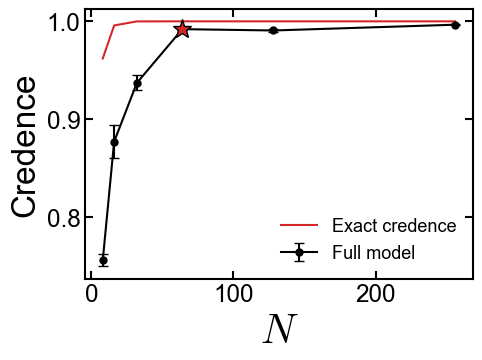

In [13]:

L = 12

g = np.array([0.2  , 0.25 , 0.3  , 0.35 , 0.375, 0.4  , 0.45 , 0.5  , 0.6  , 0.8  , 0.9, 0.975  ])
n1_l12_acc = [0.53757, 0.5656, 0.604115, 0.65314, 0.676325, 0.698445, 0.729655, 0.744845, 0.74817, 0.745885, 0.746095, 0.74927]
n2_l12_acc = [0.55508, 0.59177, 0.64665, 0.71018, 0.74172, 0.77272, 0.80815, 0.82803, 0.83126, 0.83084, 0.83068, 0.83561]
n4_l12_acc = [0.57577, 0.62885, 0.70412, 0.78733, 0.82229, 0.85328, 0.89137, 0.91031, 0.91474, 0.91396, 0.91474, 0.91733]
n8_l12_acc = [0.6067, 0.68144, 0.77757, 0.87001, 0.90593, 0.93242, 0.96127, 0.97119, 0.9753, 0.97311, 0.9733, 0.97583]
n16_l12_acc = [0.65255, 0.74683, 0.8598, 0.94404, 0.96961, 0.98239, 0.99364, 0.99638, 0.99716, 0.99725, 0.99724, 0.99751]
n32_l12_acc = [0.70828, 0.8273, 0.93566, 0.98836, 0.99598, 0.99844, 0.99972, 1.0, 0.99992, 0.99986, 0.9999, 0.99998]
n64_l12_acc = np.array([0.7808549789322097, 0.9071150461357939, 0.9838924742652941, 0.9992932956424343, 0.9998799935996586, 0.9999866659555177, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
n128_l12_acc = np.array([0.8647322381053979, 0.969596756987412, 0.9986487447549961, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
n256_l12_acc = [0.9390269924250507, 0.9962658700522778, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

exact = np.array([n1_l12_acc, n2_l12_acc, n4_l12_acc, n8_l12_acc,  \
                  n16_l12_acc, n32_l12_acc, n64_l12_acc, n128_l12_acc, n256_l12_acc])

name = {'QuAN4_Tbm2':'Inter-trajectory only', 'QuAN4_Tbt2':'Both inter/intra-trajectory', \
        'SMLP_Tbm2':'No attention', 'SMLP_Tbt2':'Intra-trajectory only'}
#cmodel = {'QuAN4_Tbt2':'tab:green', 'QuAN4_Tbm2':'tab:red', 'SMLP_Tbm2':'tab:blue'}
#shape = {'QuAN4_Tbm2':'v', 'QuAN4_Tbt2':'o', 'SMLP_Tbm2':'X', 'SMLP_Tbt2':'^'}

cmodel = {'QuAN4_Tbt2': 'tab:red', 'QuAN4_Tbm2': '#E55F2C', 'SMLP_Tbt2': '#E55F2C', 'SMLP_Tbm2': '#FDBA32'}
cmodel_e = {'QuAN4_Tbt2': sns.color_palette("dark")[3], 'QuAN4_Tbm2': sns.color_palette("dark")[1],\
            'SMLP_Tbt2': sns.color_palette("dark")[1], 'SMLP_Tbm2': '#F2A202'}
shape = {'QuAN4_Tbm2': 's', 'SMLP_Tbt2': 's', 'QuAN4_Tbt2': 'o', 'SMLP_Tbm2': 'v'}



fraction = 6000000

# fig, ax = plt.subplots(1,3,figsize=(15,3.5))
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
mn = 'QuAN4_Tbt2'; nh=1
gamma = 0.9
setsizes = np.array([8,16, 32, 64, 128, 256])
accs = np.zeros((len(setsizes), 4)); accs[:] = np.nan
for i,setsize in enumerate(setsizes):
    for run in range(4):
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h16nh{nh}_ch4ker2st1.txt'
        # if not is_non_zero_file(fn): print(fn); continue
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        #_,vl_ls,_,_,vl_ac,_,vl_ac0,_,vl_ac1,_ = np.loadtxt(fn, unpack=True)
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(accs)

ax.errorbar(setsizes, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax.plot(64, np.nanmean(accs, axis=1)[3], '*', c='tab:red', mec='k', ms=14, zorder=10)

ax.plot(setsizes, [0.96205413, 0.99580306, 0.99992835, 1.0, 1.0, 1.0], \
       c='tab:red', label='Exact credence')

print(list(exact[3:, -2]))
        
ax.set_xlabel(r'$N$', fontsize=30)
ax.set_ylabel('Credence', fontsize=24)
ax.legend()
# ax.set_yticks([50,60,70,80,90,100])

#plt.savefig('fig4.png', dpi=400, transparent=True)
plt.show()


[  8  16  32  64 128 256] [[0.77157027 0.73919845 0.7487461  0.76486444]
 [0.8500489  0.83673006 0.9068715  0.91459346]
 [0.93609554 0.9576993  0.9405148  0.91410738]
 [0.99267125 0.99206716 0.99003309 0.99330336]
 [0.99416268 0.99022013 0.98868543 0.98955023]
 [0.99713671 0.99693066 0.99627137 0.99585569]]
[ 4  8 16 32] [[0.827851   0.68481457 0.75398588 0.8159529 ]
 [0.94796115 0.94708353 0.95975071 0.95627314]
 [0.99267125 0.99206716 0.99003309 0.99330336]
 [0.99674737 0.99698371 0.9980045  0.99795353]]
[1 2 4 8] [[0.95732242 0.97962564 0.9783169  0.98560196]
 [0.98309046 0.98508555 0.98514688 0.98656052]
 [0.99267125 0.99206716 0.99003309 0.99330336]
 [0.99433869 0.99273968 0.98891979 0.99157149]]
[1 2 3] [[0.98573577 0.98864353 0.98726517 0.98513788]
 [0.99267125 0.99206716 0.99003309 0.99330336]
 [0.99095863 0.99083477 0.99279541 0.99116302]]
[1 2 3] [[0.99013776 0.99077559 0.9855569  0.98618364]
 [0.99267125 0.99206716 0.99003309 0.99330336]
 [0.99000973 0.99000978 0.98268569 0.

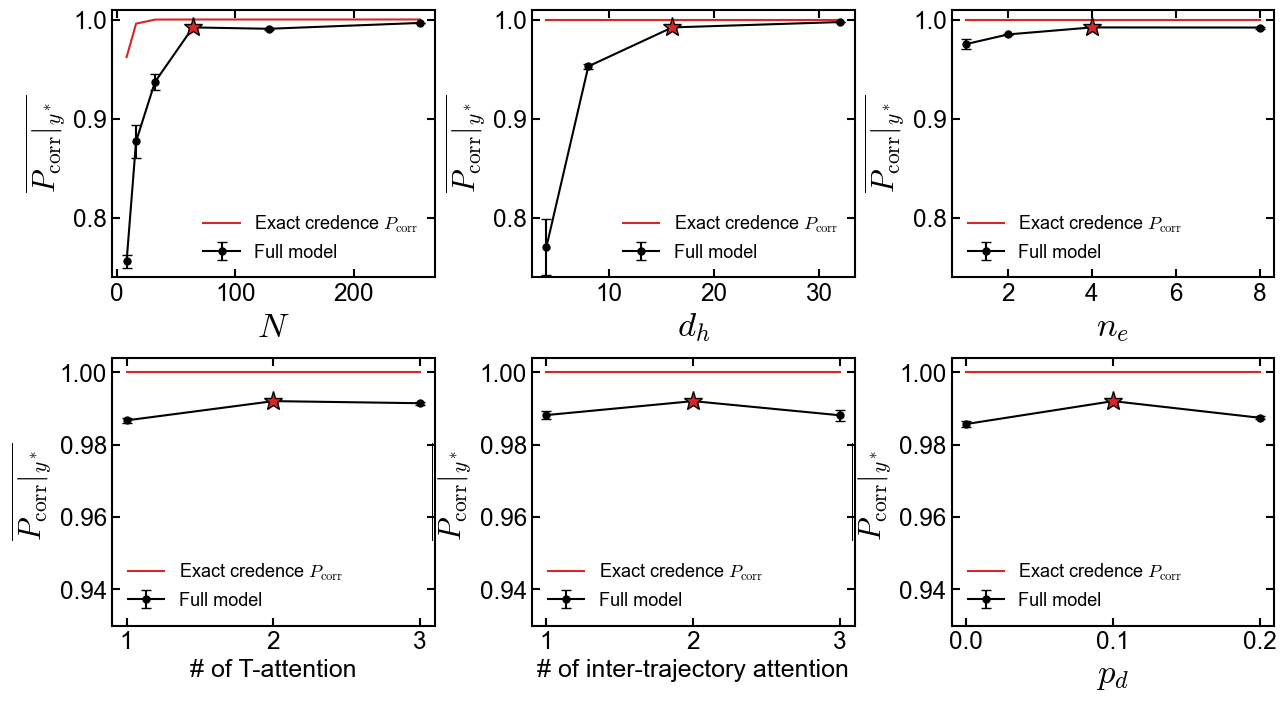

In [16]:

L = 12



name = {'QuAN4_Tbm2':'Inter-trajectory only', 'QuAN4_Tbt2':'Both inter/intra-trajectory', \
        'SMLP_Tbm2':'No attention', 'SMLP_Tbt2':'Intra-trajectory only'}

cmodel = {'QuAN4_Tbt2': 'tab:red', 'QuAN4_Tbm2': '#E55F2C', 'SMLP_Tbt2': '#E55F2C', 'SMLP_Tbm2': '#FDBA32'}
cmodel_e = {'QuAN4_Tbt2': sns.color_palette("dark")[3], 'QuAN4_Tbm2': sns.color_palette("dark")[1],\
            'SMLP_Tbt2': sns.color_palette("dark")[1], 'SMLP_Tbm2': '#F2A202'}
shape = {'QuAN4_Tbm2': 's', 'SMLP_Tbt2': 's', 'QuAN4_Tbt2': 'o', 'SMLP_Tbm2': 'v'}



fraction = 6000000
setsizes = np.array([8,16,32,64,128,256])

fig, ax = plt.subplots(2,3,figsize=(15, 8))
mn = 'QuAN4_Tbt2'; nh=1
gamma = 0.9


setsizes = np.array([8,16, 32, 64, 128, 256])
dhs = np.array([4,8,16,32])
chs = np.array([1,2,4,8])


setsize = 64
ch = 4
dh = 16
accs = np.zeros((len(setsizes), 4)); accs[:] = np.nan
for i,setsize in enumerate(setsizes):
    for run in range(4):
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h{dh}nh1_ch{ch}ker2st1.txt'
        # if not is_non_zero_file(fn): print(fn); continue
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        #_,vl_ls,_,_,vl_ac,_,vl_ac0,_,vl_ac1,_ = np.loadtxt(fn, unpack=True)
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(setsizes, accs)

ax[0,0].errorbar(setsizes, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax[0,0].plot(64, np.nanmean(accs, axis=1)[3], '*', c='tab:red', mec='k', ms=14, zorder=10)
ax[0,0].plot(setsizes, [0.96205413, 0.99580306, 0.99992835, 1.0, 1.0, 1.0], \
       c='tab:red', label=r'Exact credence $P_\mathrm{corr}$')

setsize = 64
ch = 4
dh = 16
accs = np.zeros((len(dhs), 4)); accs[:] = np.nan
for i,dh in enumerate(dhs):
    for run in range(4):
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h{dh}nh1_ch{ch}ker2st1.txt'
        # if not is_non_zero_file(fn): print(fn); continue
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        #_,vl_ls,_,_,vl_ac,_,vl_ac0,_,vl_ac1,_ = np.loadtxt(fn, unpack=True)
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(dhs, accs)
ax[0,1].errorbar(dhs, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax[0,1].plot(16, np.nanmean(accs, axis=1)[dhs==16], '*', c='tab:red', mec='k', ms=14, zorder=10)
ax[0,1].plot(dhs, np.ones_like(dhs)*exact[6, -2], \
       c='tab:red', label=r'Exact credence $P_\mathrm{corr}$')
        

setsize = 64
ch = 4
dh = 16
accs = np.zeros((len(chs), 4)); accs[:] = np.nan
for i,ch in enumerate(chs):
    for run in range(4):
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h{dh}nh1_ch{ch}ker2st1.txt'
        # if not is_non_zero_file(fn): print(fn); continue
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        #_,vl_ls,_,_,vl_ac,_,vl_ac0,_,vl_ac1,_ = np.loadtxt(fn, unpack=True)
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(chs, accs)
ax[0,2].errorbar(chs, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax[0,2].plot(4, np.nanmean(accs, axis=1)[chs==4], '*', c='tab:red', mec='k', ms=14, zorder=10)
ax[0,2].plot(chs, np.ones_like(chs)*exact[6, -2], \
       c='tab:red', label=r'Exact credence $P_\mathrm{corr}$')

ax[0,0].set_xlabel(r'$N$', fontsize=25)
ax[0,1].set_xlabel(r'$d_h$', fontsize=25)
ax[0,2].set_xlabel(r'$n_e$', fontsize=25)
ax[0,0].set_ylim(0.74, 1.01)
ax[0,1].set_ylim(0.74, 1.01)
ax[0,2].set_ylim(0.74, 1.01)
# ax[2].set_ylim(0.97, 1.001)
ax[0,0].legend()
ax[0,1].legend()
ax[0,2].legend()

nintertraj = np.array([1,2,3])
ntattn = np.array([1,2,3])
dropattn = np.array([0.0, 0.1, 0.2])

setsize = 64
ch = 4
dh = 16
accs = np.zeros((3, 4)); accs[:] = np.nan
for i,nt in enumerate(ntattn):
    for run in range(4):
        mn = f'QuAN4_Tbt{nt}'
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h{dh}nh1_ch{ch}ker2st1.txt'
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(ntattn, accs)
ax[1,0].errorbar(ntattn, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax[1,0].plot(2, np.nanmean(accs, axis=1)[ntattn==2], '*', c='tab:red', mec='k', ms=14, zorder=10)
ax[1,0].plot(ntattn, np.ones_like(ntattn)*exact[6, -2], \
       c='tab:red', label=r'Exact credence $P_\mathrm{corr}$')

mn = 'QuAN4_Tbt2'
accs = np.zeros((3, 4)); accs[:] = np.nan
for i,nint in enumerate(nintertraj):
    for run in range(4):
        mn = f'QuAN{2**nint}_Tbt2'
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h{dh}nh1_ch{ch}ker2st1.txt'
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(nintertraj, accs)
ax[1,1].errorbar(nintertraj, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax[1,1].plot(2, np.nanmean(accs, axis=1)[nintertraj==2], '*', c='tab:red', mec='k', ms=14, zorder=10)
ax[1,1].plot(nintertraj, np.ones_like(nintertraj)*exact[6, -2], \
       c='tab:red', label=r'Exact credence $P_\mathrm{corr}$')

mn = 'QuAN4_Tbt2'
accs = np.zeros((3, 4)); accs[:] = np.nan
for i,dp in enumerate(dropattn):
    for run in range(4):
        if dp==0: runadd='1'
        elif dp==0.2: runadd='2'
        elif dp==0.1: runadd=''
        fn = f'Data_out/StateDistinguish/g2_saved_models_MIPT/MIPT_{mn}_L{L}_g{gamma}_run_{runadd}{run}/'\
        +f'cred_{L}_g{gamma}_0vs{fraction}-{mn}_set{setsize}__h{dh}nh1_ch{ch}ker2st1.txt'
        if not (os.path.isfile(fn) and os.path.getsize(fn)): continue
        accs[i, run] = np.loadtxt(fn, unpack=True)[1]
print(dropattn, accs)
ax[1,2].errorbar(dropattn, np.nanmean(accs, axis=1), np.nanstd(accs, axis=1)/2,\
           fmt='.-', c='k', capsize=3.5, ms=10, label='Full model')
ax[1,2].plot(0.1, np.nanmean(accs, axis=1)[dropattn==0.1], '*', c='tab:red', mec='k', ms=14, zorder=10)
ax[1,2].plot(dropattn, np.ones_like(dropattn)*exact[6, -2], \
       c='tab:red', label=r'Exact credence $P_\mathrm{corr}$')



ax[1,0].set_xlabel(r'# of T-attention', fontsize=18)
ax[1,1].set_xlabel(r'# of inter-trajectory attention', fontsize=18)
ax[1,2].set_xlabel(r'$p_d$', fontsize=25)
ax[1,0].set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax[1,1].set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax[1,2].set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax[0,0].set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax[0,1].set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax[0,2].set_ylabel(r'$\overline{P_\mathrm{corr}|_{y^*}}$', fontsize=22)
ax[1,0].set_ylim(0.93, 1.004)
ax[1,1].set_ylim(0.93, 1.004)
ax[1,2].set_ylim(0.93, 1.004)
# ax[2].set_ylim(0.97, 1.001)
ax[1,0].legend()
ax[1,1].legend()
ax[1,2].legend()




fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()
